<a href="https://colab.research.google.com/github/red-gunslinger/Int-Comp/blob/main/Feed_Forward_Network_con_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Feed Forward Network con PyTorch

Sofia Gabriela Aguilar 36019

Here, three feed forward neural networks are implemented, trained, and evaluated using pytorch and the MNIST dataset. The goal is to classify handwritten digits from 0 to 9.

In [19]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

MNIST is loaded as a PyTorch dataset. The original MNIST training split contains 60,000 images and the original test split contains 10,000 images.

In [20]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


MNIST is loaded as a PyTorch dataset. The original MNIST training split contains 50,000+ images and the original test split contains 10,000.

In [21]:
transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [50000, 10000],
    generator=torch.Generator().manual_seed(seed)
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 50000
Validation size: 10000
Test size: 10000


The dataset is processed in mini-batches using data loaders. Training batches are shuffled, while validation and test batches are not shuffled.

In [22]:
default_batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=default_batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=default_batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=default_batch_size, shuffle=False)

Before training the models, a few examples from the dataset are shown here. Each one is a grayscale handwritten digit.

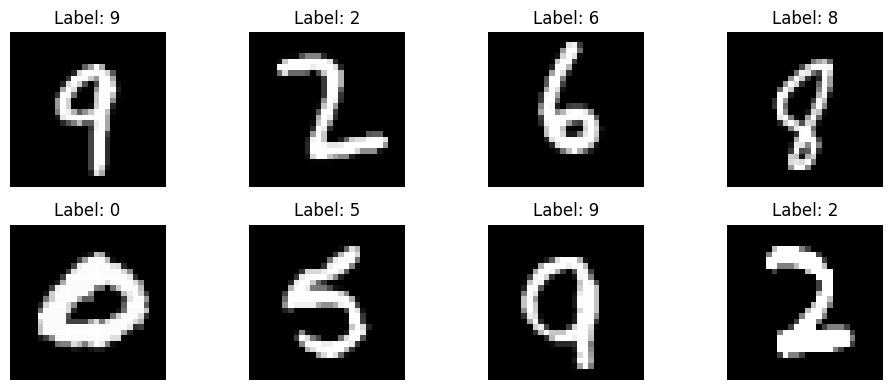

In [23]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Only nn.Linear and nn.ReLU layers are used in the hidden architecture.

In [24]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_layers, num_classes):
        super().__init__()

        layers = []
        previous_size = input_size

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(previous_size, hidden_size))
            layers.append(nn.ReLU())
            previous_size = hidden_size

        layers.append(nn.Linear(previous_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

helper functions are used to compute accuracy, evaluate a model, apply early stopping, and train the models with a manual loop.

In [25]:
def evaluate_model(model, data_loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            predictions = torch.argmax(outputs, dim=1)
            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy

In [26]:
class EarlyStopping:
    def __init__(self, patience=3, delta=0.005):
        self.patience = patience
        self.delta = delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None
        self.stop = False

    def step(self, current_loss, model):
        if self.best_loss - current_loss > self.delta:
            self.best_loss = current_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

In [27]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, patience=3, delta=0.005):
    model.to(device)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    early_stopping = EarlyStopping(patience=patience, delta=delta)

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        running_correct = 0
        total_samples = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            predictions = torch.argmax(outputs, dim=1)
            running_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

        train_loss = running_loss / total_samples
        train_acc = running_correct / total_samples

        val_loss, val_acc = evaluate_model(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        early_stopping.step(val_loss, model)

        if early_stopping.stop:
            print("Early stopping activated.")
            break

    if early_stopping.best_state is not None:
        model.load_state_dict(early_stopping.best_state)

    return model, history

three different NN are trained by modifying the architecture and hyperparameters.

In [28]:
model_configs = {
    "Model_1": {
        "hidden_layers": [128],
        "optimizer": "SGD",
        "learning_rate": 0.01,
        "batch_size": 128,
        "epochs": 15
    },
    "Model_2": {
        "hidden_layers": [256, 128],
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "batch_size": 128,
        "epochs": 20
    },
    "Model_3": {
        "hidden_layers": [512, 256, 128],
        "optimizer": "Adam",
        "learning_rate": 0.0005,
        "batch_size": 64,
        "epochs": 20
    }
}

each model is trained independently.
At the end of training, validation loss and validation accuracy are saved to compare the models and choose the best one.

In [29]:
criterion = nn.CrossEntropyLoss()

results = {}
trained_models = {}
histories = {}

for model_name, config in model_configs.items():
    print("=" * 60)
    print(f"Training {model_name}")
    print("=" * 60)

    current_train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True
    )

    current_val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False
    )

    model = MLP(
        input_size=784,
        hidden_layers=config["hidden_layers"],
        num_classes=10
    )

    if config["optimizer"] == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=config["learning_rate"])
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])

    model, history = train_model(
        model=model,
        train_loader=current_train_loader,
        val_loader=current_val_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=config["epochs"],
        patience=3,
        delta=0.005
    )

    val_loss, val_acc = evaluate_model(model, current_val_loader, criterion)

    results[model_name] = {
        "val_loss": val_loss,
        "val_acc": val_acc,
        "config": config
    }

    trained_models[model_name] = model
    histories[model_name] = history

Training Model_1
Epoch 1/15 | Train Loss: 1.7987 | Train Acc: 0.6292 | Val Loss: 1.2094 | Val Acc: 0.7940
Epoch 2/15 | Train Loss: 0.8850 | Train Acc: 0.8270 | Val Loss: 0.6871 | Val Acc: 0.8519
Epoch 3/15 | Train Loss: 0.5933 | Train Acc: 0.8612 | Val Loss: 0.5329 | Val Acc: 0.8717
Epoch 4/15 | Train Loss: 0.4879 | Train Acc: 0.8768 | Val Loss: 0.4629 | Val Acc: 0.8819
Epoch 5/15 | Train Loss: 0.4336 | Train Acc: 0.8856 | Val Loss: 0.4224 | Val Acc: 0.8876
Epoch 6/15 | Train Loss: 0.4004 | Train Acc: 0.8921 | Val Loss: 0.3968 | Val Acc: 0.8918
Epoch 7/15 | Train Loss: 0.3776 | Train Acc: 0.8961 | Val Loss: 0.3783 | Val Acc: 0.8940
Epoch 8/15 | Train Loss: 0.3606 | Train Acc: 0.9002 | Val Loss: 0.3639 | Val Acc: 0.8966
Epoch 9/15 | Train Loss: 0.3471 | Train Acc: 0.9035 | Val Loss: 0.3523 | Val Acc: 0.8983
Epoch 10/15 | Train Loss: 0.3360 | Train Acc: 0.9064 | Val Loss: 0.3427 | Val Acc: 0.9018
Epoch 11/15 | Train Loss: 0.3264 | Train Acc: 0.9084 | Val Loss: 0.3341 | Val Acc: 0.9041
Ep

the three models are compared using validation performance. The best model is the one with the best validation accuracy

In [30]:
for model_name, result in results.items():
    print(model_name)
    print("Validation Loss:", round(result["val_loss"], 4))
    print("Validation Accuracy:", round(result["val_acc"], 4))
    print("Configuration:", result["config"])
    print()

Model_1
Validation Loss: 0.3082
Validation Accuracy: 0.9109
Configuration: {'hidden_layers': [128], 'optimizer': 'SGD', 'learning_rate': 0.01, 'batch_size': 128, 'epochs': 15}

Model_2
Validation Loss: 0.0866
Validation Accuracy: 0.9747
Configuration: {'hidden_layers': [256, 128], 'optimizer': 'Adam', 'learning_rate': 0.001, 'batch_size': 128, 'epochs': 20}

Model_3
Validation Loss: 0.0836
Validation Accuracy: 0.9764
Configuration: {'hidden_layers': [512, 256, 128], 'optimizer': 'Adam', 'learning_rate': 0.0005, 'batch_size': 64, 'epochs': 20}



In [31]:
best_model_name = max(results, key=lambda name: results[name]["val_acc"])
best_model = trained_models[best_model_name]

print("Selected best model:", best_model_name)
print("Best validation accuracy:", round(results[best_model_name]["val_acc"], 4))

Selected best model: Model_3
Best validation accuracy: 0.9764


the following plots show training loss, validation loss, etc. for each model across epochs.
the curves help see and compare models.

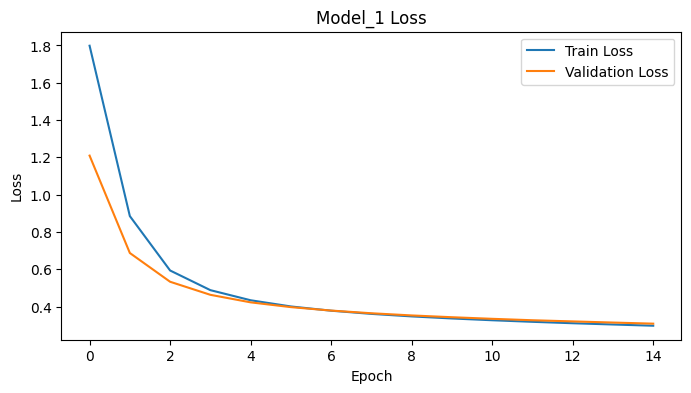

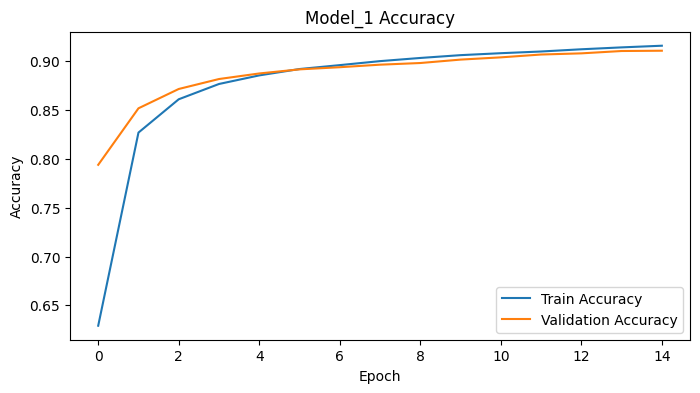

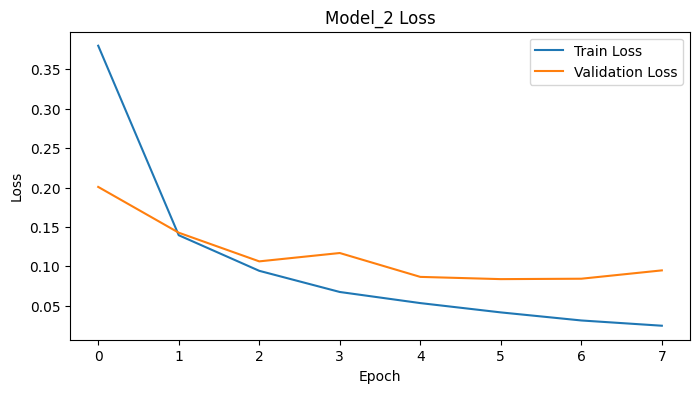

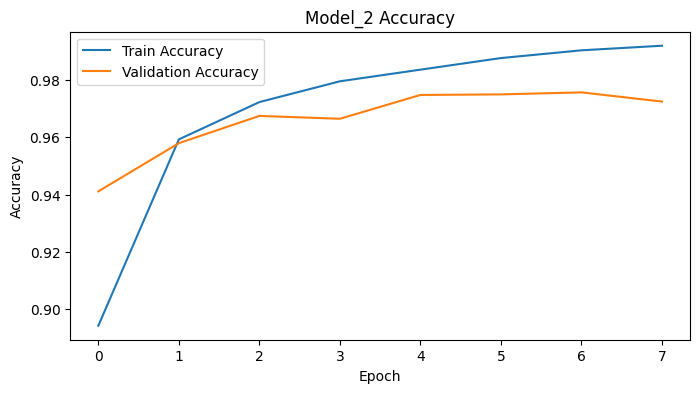

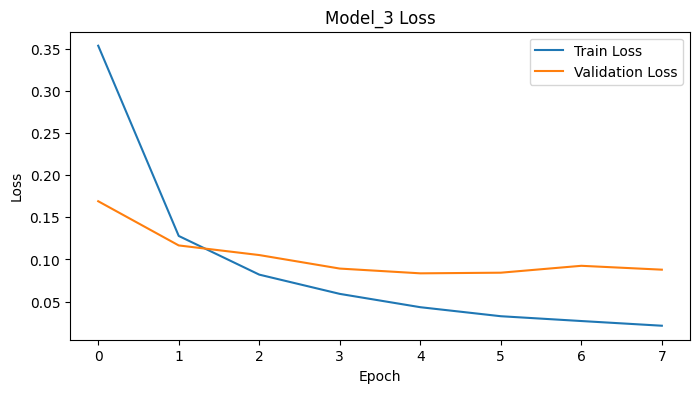

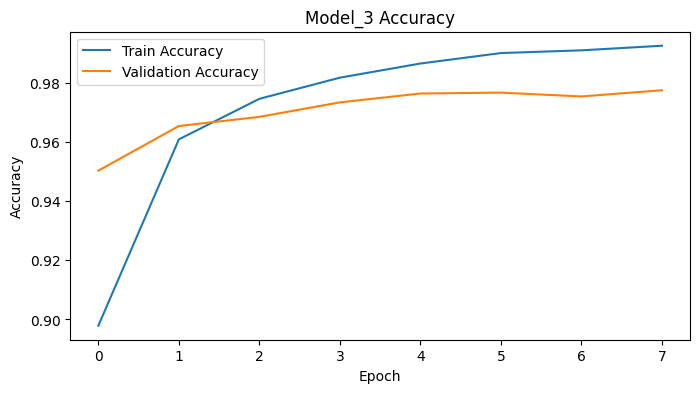

In [32]:
for model_name, history in histories.items():
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

after selecting the best model using validation accuracy, said model is evaluated on the test set. This gives the final loss and accuracy for the model on previously unseen data.

In [33]:
best_batch_size = results[best_model_name]["config"]["batch_size"]

best_test_loader = DataLoader(
    test_dataset,
    batch_size=best_batch_size,
    shuffle=False
)

test_loss, test_acc = evaluate_model(best_model, best_test_loader, criterion)

print("Best Model:", best_model_name)
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))

Best Model: Model_3
Test Loss: 0.0746
Test Accuracy: 0.9782


In [34]:
def get_predictions(model, data_loader):
    model.eval()

    all_true = []
    all_pred = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1).cpu().numpy()

            all_true.extend(labels.numpy())
            all_pred.extend(predictions)

    return np.array(all_true), np.array(all_pred)

In [35]:
def confusion_matrix_manual(y_true, y_pred, num_classes=10):
    cm = np.zeros((num_classes, num_classes), dtype=int)

    for true_label, predicted_label in zip(y_true, y_pred):
        cm[true_label, predicted_label] += 1

    return cm

In [36]:
def classification_report_manual(y_true, y_pred, num_classes=10):
    cm = confusion_matrix_manual(y_true, y_pred, num_classes)
    global_accuracy = np.trace(cm) / np.sum(cm)

    precision_per_class = []
    recall_per_class = []
    f1_per_class = []

    for i in range(num_classes):
        true_positive = cm[i, i]
        false_positive = cm[:, i].sum() - true_positive
        false_negative = cm[i, :].sum() - true_positive

        precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0.0
        recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0.0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

        precision_per_class.append(precision)
        recall_per_class.append(recall)
        f1_per_class.append(f1)

    return cm, global_accuracy, precision_per_class, recall_per_class, f1_per_class

In [37]:
y_true, y_pred = get_predictions(best_model, best_test_loader)

cm, global_accuracy, precision_per_class, recall_per_class, f1_per_class = classification_report_manual(
    y_true,
    y_pred,
    num_classes=10
)

print("Global Accuracy:", round(global_accuracy, 4))
print()

for i in range(10):
    print(
        f"Class {i} | "
        f"Precision: {precision_per_class[i]:.4f} | "
        f"Recall: {recall_per_class[i]:.4f} | "
        f"F1-score: {f1_per_class[i]:.4f}"
    )

Global Accuracy: 0.9782

Class 0 | Precision: 0.9798 | Recall: 0.9908 | F1-score: 0.9853
Class 1 | Precision: 0.9938 | Recall: 0.9912 | F1-score: 0.9925
Class 2 | Precision: 0.9640 | Recall: 0.9874 | F1-score: 0.9756
Class 3 | Precision: 0.9678 | Recall: 0.9812 | F1-score: 0.9744
Class 4 | Precision: 0.9815 | Recall: 0.9735 | F1-score: 0.9775
Class 5 | Precision: 0.9818 | Recall: 0.9686 | F1-score: 0.9752
Class 6 | Precision: 0.9968 | Recall: 0.9708 | F1-score: 0.9836
Class 7 | Precision: 0.9775 | Recall: 0.9708 | F1-score: 0.9741
Class 8 | Precision: 0.9722 | Recall: 0.9682 | F1-score: 0.9702
Class 9 | Precision: 0.9676 | Recall: 0.9762 | F1-score: 0.9719


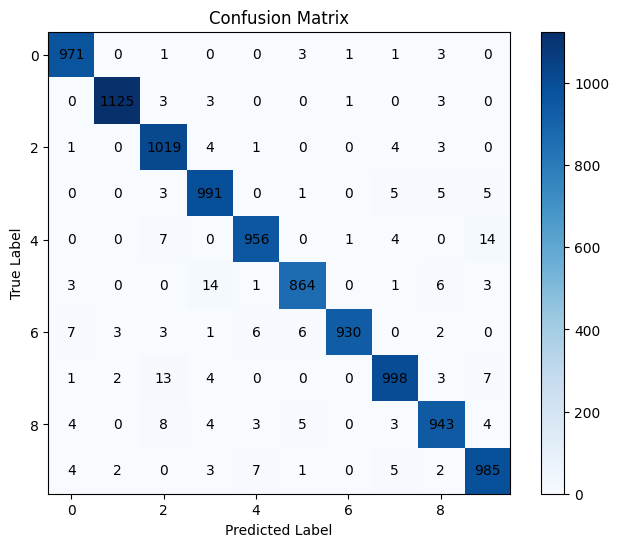

In [38]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.show()

the selected model's stats are below. It was chosen using validation accuracy and then evaluated on the test set as said prior.

In [39]:
print("Best model:", best_model_name)
print("Best model configuration:", results[best_model_name]["config"])
print("Validation loss:", round(results[best_model_name]["val_loss"], 4))
print("Validation accuracy:", round(results[best_model_name]["val_acc"], 4))
print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_acc, 4))

Best model: Model_3
Best model configuration: {'hidden_layers': [512, 256, 128], 'optimizer': 'Adam', 'learning_rate': 0.0005, 'batch_size': 64, 'epochs': 20}
Validation loss: 0.0836
Validation accuracy: 0.9764
Test loss: 0.0746
Test accuracy: 0.9782


## Personal Reflections

This activity personally helped me understand PyTorch. An important observation was that changing the architecture and hyperparameters produced different kinds of validation results. The deeper models normally performed better, but they also required more computation. This showed that model design and parameter selection have a direct impact on performance. It took a bit of time to compile some sections, I don't know if it was my wi-fi, since it's been struggling this week. Separating the data was also important. The validation set allowed the three models to be compared fairly before being able to choose the final one, and the test set was reserved for the final evaluation. This helped avoid selecting a model directly from purely test performance. Implementing early stopping and the classification report manually helped reinforce how these tools work internally instead of only using automated functions.

https://www.geeksforgeeks.org/deep-learning/feedforward-neural-network/